# 03 Exploratory Data Analysis

本 Notebook 依據 Jain et al. (2024) *Predicting hospital length of stay using machine learning on a large open health dataset* 之 Methods 與 Results 進行探索性資料分析（Exploratory Data Analysis, EDA）。

本章重點為**重現原論文與 EDA 相關之表格與圖形**，包含：

1. Table 1：Length of Stay 描述性統計。
2. Figure 3：Length of Stay histogram。
3. Figure 4：Length of Stay density plot。
4. Figure 5：Newborn Length of Stay density plot。
5. Table 2：Top 20 APR DRG。
6. Figure 6：Top 20 APR DRG 與 Length of Stay 分布。

最後另加入 Reanalysis，作為後續特徵工程與模型建立之基礎。

## 3.1 載入套件與設定路徑

本節載入 EDA 所需套件，並設定資料、圖檔與輸出表格之相對路徑。

為提高可重現性，本章盡量使用 `tidyverse`、`data.table` 與 base R 繪圖功能，不依賴額外視覺化套件。

In [68]:
library(tidyverse)
library(data.table)
library(skimr)
library(janitor)
library(scales)

processed_path <- "../data/processed"
raw_path <- "../data/raw"
figure_path <- "../figures"
output_path <- "../output"

dir.create(figure_path, showWarnings = FALSE, recursive = TRUE)
dir.create(output_path, showWarnings = FALSE, recursive = TRUE)

# 原論文圖表近似色
paper_blue <- "#2B8CBE"
paper_edge <- "#1B4F72"
paper_line <- "#0072B2"

theme_paper_hist <- function(base_size = 14) {
  theme_classic(base_size = base_size) +
    theme(
      axis.title = element_text(size = base_size + 1),
      axis.text = element_text(size = base_size - 1),
      axis.line = element_line(colour = "black", linewidth = 0.6),
      panel.grid = element_blank(),
      plot.title = element_blank(),
      legend.position = "none"
    )
}

theme_paper_density <- function(base_size = 14) {
  theme_classic(base_size = base_size) +
    theme(
      axis.title = element_text(size = base_size + 1),
      axis.text = element_text(size = base_size - 1),
      axis.line = element_line(colour = "black", linewidth = 0.6),
      panel.grid = element_blank(),
      plot.title = element_blank()
    )
}


Attaching package: ‘scales’


The following object is masked from ‘package:viridis’:

    viridis_pal


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




## 3.2 讀取前處理後資料

本節讀取 `02_Preprocessing.ipynb` 產生之前處理完成資料。

後續分析以完整前處理資料 `df_clean` 為主，並保留 `df_newborn` 與 `df_non_newborn` 作為分層分析使用。原論文亦將 newborn 與 non-newborn 分開建模。

In [69]:
df_clean <- readRDS(
  file.path(processed_path, "df_clean.rds")
)

df_newborn <- readRDS(
  file.path(processed_path, "df_newborn.rds")
)

df_non_newborn <- readRDS(
  file.path(processed_path, "df_non_newborn.rds")
)

cat("df_clean：", nrow(df_clean), "筆 ×", ncol(df_clean), "欄\n")
cat("df_newborn：", nrow(df_newborn), "筆 ×", ncol(df_newborn), "欄\n")
cat("df_non_newborn：", nrow(df_non_newborn), "筆 ×", ncol(df_non_newborn), "欄\n")

df_clean： 2338104 筆 × 25 欄
df_newborn： 229290 筆 × 25 欄
df_non_newborn： 2108814 筆 × 24 欄


## 3.3 Dataset Overview

本節確認資料維度、欄位型態、缺失值與重複資料。此步驟僅作為 EDA 前確認，不再重新進行資料清理。

In [70]:
eda_dimension_summary <- tibble(
  Dataset = c("Complete dataset", "Newborn", "Non-newborn"),
  Rows = c(nrow(df_clean), nrow(df_newborn), nrow(df_non_newborn)),
  Columns = c(ncol(df_clean), ncol(df_newborn), ncol(df_non_newborn))
)

eda_dimension_summary

Dataset,Rows,Columns
<chr>,<int>,<int>
Complete dataset,2338104,25
Newborn,229290,25
Non-newborn,2108814,24


In [71]:
variable_overview <- tibble(
  Variable = names(df_clean),
  Class = sapply(df_clean, function(x) paste(class(x), collapse = ", ")),
  Missing = sapply(df_clean, function(x) sum(is.na(x))),
  Missing_Percentage = round(
    sapply(df_clean, function(x) mean(is.na(x)) * 100),
    2
  ),
  Unique_Values = sapply(df_clean, function(x) length(unique(x)))
)

variable_overview

Variable,Class,Missing,Missing_Percentage,Unique_Values
<chr>,<chr>,<int>,<dbl>,<int>
Health Service Area,character,0,0.00,8
Hospital County,character,0,0.00,57
Operating Certificate Number,integer,0,0.00,174
Facility Id,character,0,0.00,211
Facility Name,character,0,0.00,213
Age Group,character,0,0.00,5
Zip Code - 3 digits,character,0,0.00,51
Gender,character,0,0.00,3
Race,character,0,0.00,4


In [72]:
duplicate_summary <- tibble(
  Dataset = c("Complete dataset", "Newborn", "Non-newborn"),
  Duplicated_Rows = c(
    sum(duplicated(df_clean)),
    sum(duplicated(df_newborn)),
    sum(duplicated(df_non_newborn))
  )
)

duplicate_summary

Dataset,Duplicated_Rows
<chr>,<int>
Complete dataset,178737
Newborn,53207
Non-newborn,125530


In [73]:
write.csv(
  eda_dimension_summary,
  file.path(output_path, "EDA_Dataset_Dimension.csv"),
  row.names = FALSE
)

write.csv(
  variable_overview,
  file.path(output_path, "EDA_Variable_Overview.csv"),
  row.names = FALSE
)

write.csv(
  duplicate_summary,
  file.path(output_path, "EDA_Duplicate_Summary.csv"),
  row.names = FALSE
)

## 3.4 建立分析用 Length of Stay 數值欄位

原始 `Length of Stay` 欄位為字元型態。原論文指出資料提供者將住院天數截斷於 120 天，因此本節將 `120 +` 或類似格式轉換為數值 120，建立 `Length_of_Stay_Days` 作為分析欄位。

注意：本節不覆蓋原始 `Length of Stay` 欄位。

In [74]:
convert_los <- function(x) {
  x <- as.character(x)
  x <- stringr::str_trim(x)
  x <- stringr::str_replace_all(x, "\\+", "")
  x <- stringr::str_trim(x)
  as.numeric(x)
}

df_clean <- df_clean %>%
  mutate(
    Length_of_Stay_Days = convert_los(`Length of Stay`)
  )

df_newborn <- df_newborn %>%
  mutate(
    Length_of_Stay_Days = convert_los(`Length of Stay`)
  )

df_non_newborn <- df_non_newborn %>%
  mutate(
    Length_of_Stay_Days = convert_los(`Length of Stay`)
  )

summary(df_clean$Length_of_Stay_Days)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   2.000   3.000   5.414   6.000 120.000 

In [75]:
los_conversion_check <- tibble(
  Dataset = c("Complete dataset", "Newborn", "Non-newborn"),
  Missing_LOS_After_Conversion = c(
    sum(is.na(df_clean$Length_of_Stay_Days)),
    sum(is.na(df_newborn$Length_of_Stay_Days)),
    sum(is.na(df_non_newborn$Length_of_Stay_Days))
  )
)

los_conversion_check

Dataset,Missing_LOS_After_Conversion
<chr>,<int>
Complete dataset,0
Newborn,0
Non-newborn,0


## 3.5 Table 1：Length of Stay 描述性統計

原論文 Table 1 呈現 LoS 的平均值、標準差、最小值、四分位數與最大值。本節使用目前前處理後資料重現該表。

In [76]:
table_los_statistics <- tibble(
  Statistic = c(
    "Mean",
    "std. deviation",
    "Minimum",
    "25th percentile",
    "50th percentile",
    "75th percentile",
    "Maximum"
  ),
  Value = c(
    round(mean(df_clean$Length_of_Stay_Days, na.rm = TRUE), 2),
    round(sd(df_clean$Length_of_Stay_Days, na.rm = TRUE), 2),
    round(min(df_clean$Length_of_Stay_Days, na.rm = TRUE), 2),
    round(as.numeric(quantile(df_clean$Length_of_Stay_Days, 0.25, na.rm = TRUE)), 2),
    round(as.numeric(quantile(df_clean$Length_of_Stay_Days, 0.50, na.rm = TRUE)), 2),
    round(as.numeric(quantile(df_clean$Length_of_Stay_Days, 0.75, na.rm = TRUE)), 2),
    round(max(df_clean$Length_of_Stay_Days, na.rm = TRUE), 2)
  )
)

table_los_statistics

Statistic,Value
<chr>,<dbl>
Mean,5.41
std. deviation,7.97
Minimum,1.00
25th percentile,2.00
50th percentile,3.00
75th percentile,6.00
Maximum,120.00


In [77]:
write.csv(
  table_los_statistics,
  file.path(output_path, "Reproduced_Table_1_LOS_Statistics.csv"),
  row.names = FALSE
)

## 3.6 Figure 3：Distribution of Length of Stay

原論文 Figure 3 為 LoS 的 histogram，Y 軸使用 log10 scale，X 軸範圍約為 0–120，X 軸標籤為 `Length of Stay`，Y 軸標籤為 `Count`。

為避免 log scale 下 0 count bin 產生警告，本節先建立 LoS frequency table，再使用 `geom_col()` 繪圖。

In [78]:
los_hist_data <- df_clean %>%
  filter(!is.na(Length_of_Stay_Days)) %>%
  count(Length_of_Stay_Days, name = "Count") %>%
  filter(
    Length_of_Stay_Days >= 1,
    Length_of_Stay_Days <= 120,
    Count > 0
  )

head(los_hist_data)

Length_of_Stay_Days,Count
<dbl>,<int>
1,345292
2,545931
3,423516
4,244968
5,159895
6,114752


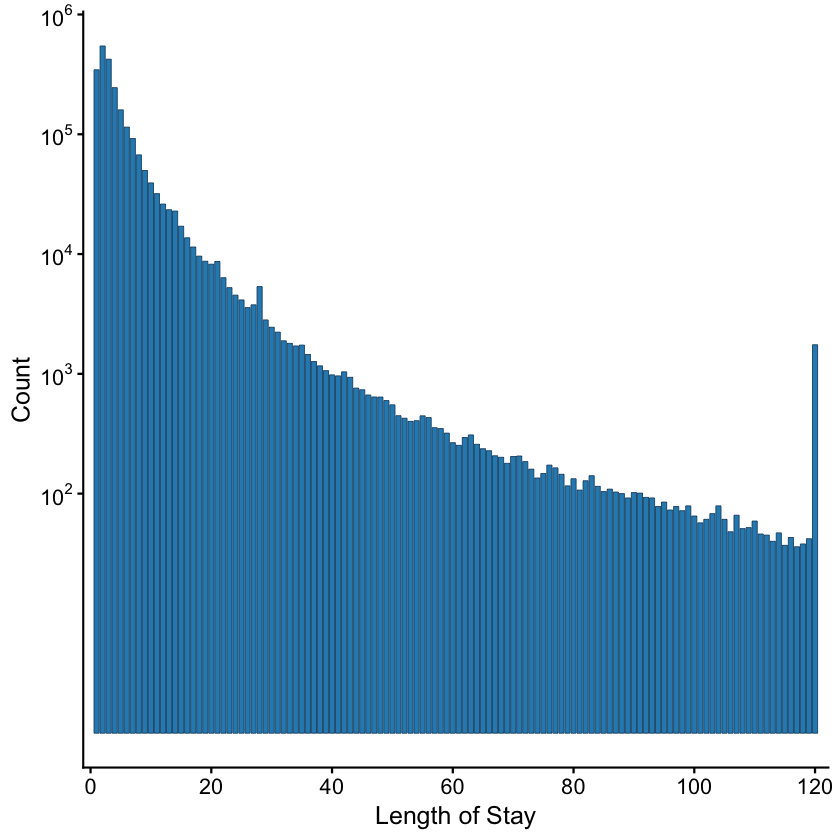

In [79]:
fig_los_hist <- ggplot(
  los_hist_data,
  aes(
    x = Length_of_Stay_Days,
    y = Count
  )
) +
  geom_col(
    width = 0.85,
    fill = paper_blue,
    color = paper_edge,
    linewidth = 0.25
  ) +
  scale_x_continuous(
    breaks = seq(0, 120, 20),
    limits = c(0, 121),
    expand = c(0.01, 0)
  ) +
  scale_y_log10(
    breaks = 10^(2:6),
    labels = scales::trans_format("log10", scales::math_format(10^.x))
  ) +
  labs(
    title = NULL,
    x = "Length of Stay",
    y = "Count"
  ) +
  theme_paper_hist(base_size = 14)

fig_los_hist

In [80]:
ggsave(
  filename = file.path(figure_path, "Figure_03_Distribution_of_Length_of_Stay.png"),
  plot = fig_los_hist,
  width = 8,
  height = 6,
  dpi = 300,
  bg = "white"
)

## 3.7 Figure 4：Density Plot of Length of Stay

原論文 Figure 4 為 LoS 的 density plot，X 軸約為 0–120，Y 軸為 Density。

由於 LoS 為整數型住院天數，直接使用 `geom_density()` 容易產生過度尖銳的波形。本節使用 `density()` 並設定 Gaussian kernel 與平滑參數，以接近原論文之曲線樣式。

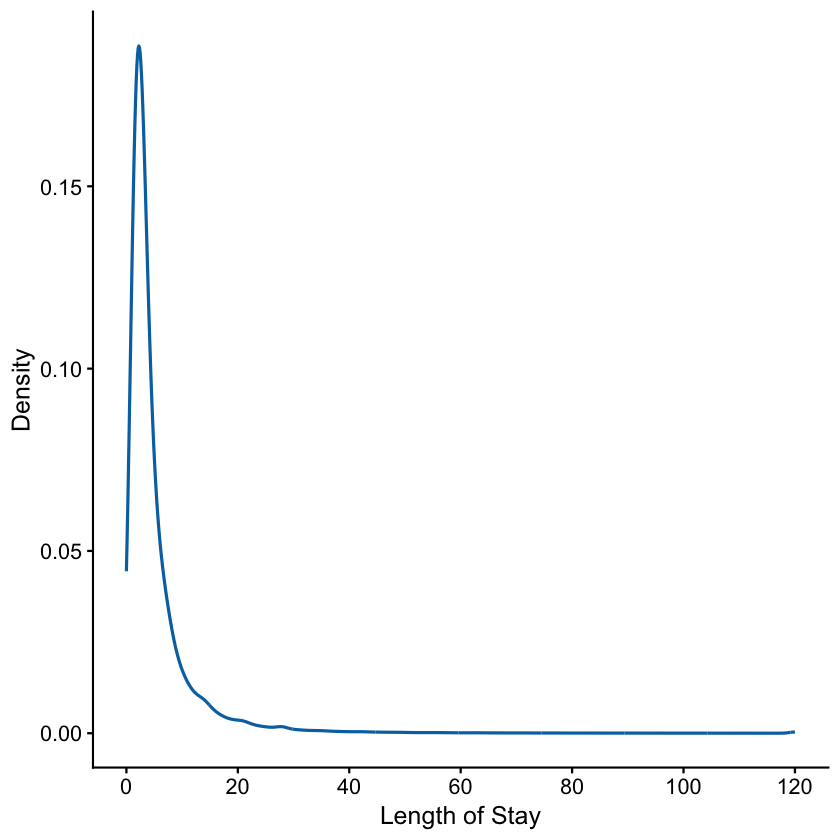

In [81]:
los_density_object <- density(
  df_clean$Length_of_Stay_Days,
  na.rm = TRUE,
  from = 0,
  to = 120,
  n = 1024,
  bw = 0.9,
  kernel = "gaussian"
)

los_density_data <- tibble(
  Length_of_Stay = los_density_object$x,
  Density = los_density_object$y
)

fig_los_density <- ggplot(
  los_density_data,
  aes(
    x = Length_of_Stay,
    y = Density
  )
) +
  geom_line(
    color = paper_line,
    linewidth = 0.9
  ) +
  scale_x_continuous(
    breaks = seq(0, 120, 20),
    limits = c(0, 120)
  ) +
  labs(
    title = NULL,
    x = "Length of Stay",
    y = "Density"
  ) +
  theme_paper_density(base_size = 14)

fig_los_density

In [82]:
ggsave(
  filename = file.path(figure_path, "Figure_04_Density_Plot_of_Length_of_Stay.png"),
  plot = fig_los_density,
  width = 8,
  height = 6,
  dpi = 300,
  bg = "white"
)

## 3.8 Figure 5：Distribution of Length of Stay for Newborns

原論文 Figure 5 呈現 newborns 的 LoS 分布，圖型為 density plot，X 軸主要顯示 0–9 天，Y 軸為 Density，並包含右上角 legend：`Length of Stay`。

直接對整數 LoS 使用 `geom_density()` 會產生不符合原論文的尖峰狀圖形。因此本節使用 `density()` 設定 Gaussian kernel 與較大的 bandwidth，重現原論文之平滑密度曲線。

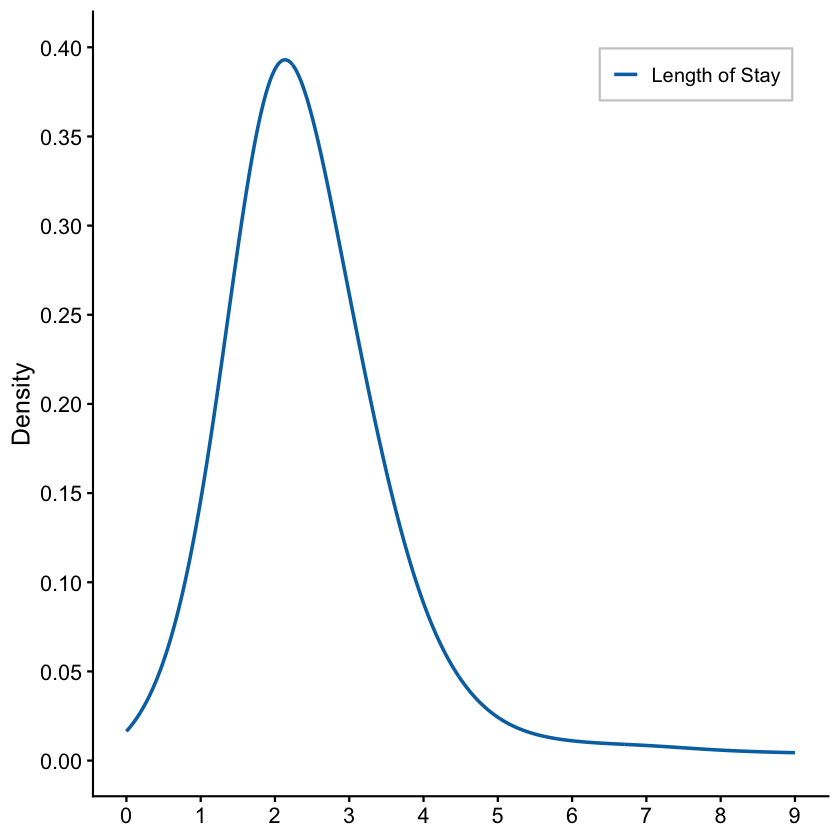

In [83]:
newborn_los_density_object <- density(
  df_newborn$Length_of_Stay_Days,
  na.rm = TRUE,
  from = 0,
  to = 9,
  n = 512,
  bw = 0.65,
  kernel = "gaussian"
)

newborn_los_density_data <- tibble(
  Length_of_Stay = newborn_los_density_object$x,
  Density = newborn_los_density_object$y
)

fig_newborn_los_density <- ggplot(
  newborn_los_density_data,
  aes(
    x = Length_of_Stay,
    y = Density,
    color = "Length of Stay"
  )
) +
  geom_line(
    linewidth = 1.0
  ) +
  scale_color_manual(
    values = c("Length of Stay" = paper_line),
    name = NULL
  ) +
  scale_x_continuous(
    breaks = seq(0, 9, 1),
    limits = c(0, 9)
  ) +
  scale_y_continuous(
    breaks = seq(0, 0.40, 0.05),
    limits = c(0, 0.40)
  ) +
  labs(
    title = NULL,
    x = NULL,
    y = "Density"
  ) +
  theme_paper_density(base_size = 14) +
  theme(
    legend.position = c(0.82, 0.92),
    legend.background = element_rect(fill = "white", color = "grey80"),
    legend.text = element_text(size = 12)
  )

fig_newborn_los_density

In [84]:
ggsave(
  filename = file.path(figure_path, "Figure_05_Distribution_of_Length_of_Stay_for_Newborns.png"),
  plot = fig_newborn_los_density,
  width = 8,
  height = 6,
  dpi = 300,
  bg = "white"
)

## 3.9 Table 2：Top 20 APR DRG

原論文 Table 2 呈現資料集中最常見的前 20 個 APR DRG descriptions。

由於 `02_Preprocessing.ipynb` 已移除描述性欄位，本節優先嘗試從 `data/raw/` 讀取原始資料以補回 `APR DRG Description`。若原始資料不可讀，則以 `APR DRG Code` 呈現。

In [85]:
apr_drg_lookup <- NULL

if ("APR DRG Description" %in% names(df_clean)) {

  apr_drg_lookup <- df_clean %>%
    select(`APR DRG Code`, `APR DRG Description`) %>%
    distinct()

} else {

  raw_files <- list.files(
    raw_path,
    pattern = "\\.csv$",
    full.names = TRUE
  )

  if (length(raw_files) > 0) {

    raw_for_lookup <- tryCatch(
      {
        data.table::fread(
          raw_files[1],
          select = c("APR DRG Code", "APR DRG Description"),
          showProgress = FALSE
        )
      },
      error = function(e) NULL
    )

    if (!is.null(raw_for_lookup)) {
      apr_drg_lookup <- raw_for_lookup %>%
        as_tibble() %>%
        distinct()
    }
  }
}

is.null(apr_drg_lookup)

[1] FALSE

In [86]:
table_top20_apr_drg <- df_clean %>%
  count(`APR DRG Code`, sort = TRUE) %>%
  slice_head(n = 20) %>%
  rename(
    `APR DRG Code` = `APR DRG Code`,
    Frequency = n
  )

if (!is.null(apr_drg_lookup)) {
  table_top20_apr_drg <- table_top20_apr_drg %>%
    left_join(
      apr_drg_lookup,
      by = "APR DRG Code"
    ) %>%
    select(
      `APR DRG Description`,
      Frequency,
      `APR DRG Code`
    )
} else {
  table_top20_apr_drg <- table_top20_apr_drg %>%
    select(
      `APR DRG Code`,
      Frequency
    )
}

table_top20_apr_drg

APR DRG Description,Frequency,APR DRG Code
<chr>,<int>,<int>
"Neonate birthwt >2499g, normal newborn or neonate w other problem",195055,640
Vaginal delivery,141887,560
Septicemia & disseminated infections,93295,720
Cesarean delivery,74520,540
Heart failure,56688,194
Other pneumonia,40835,139
Knee joint replacement,39800,302
Chronic obstructive pulmonary disease,38009,140
Schizophrenia,36284,750


In [87]:
write.csv(
  table_top20_apr_drg,
  file.path(output_path, "Reproduced_Table_2_Top20_APR_DRG.csv"),
  row.names = FALSE
)

## 3.10 Figure 6：Top 20 APR DRG 與 Length of Stay 分布

原論文 Figure 6 使用 3D plot 呈現 Top 20 APR DRG descriptions 的 LoS 分布，X 軸為 Length of Stay，Y 軸為 APR DRG，Z 軸為 density 或 frequency。

本節使用 base R `persp()` 建立 3D surface plot，以維持與原論文相同的圖表類型。由於 R base 3D 圖對長文字標籤支援有限，Y 軸使用前 20 個 APR DRG 的排序編號，對應關係已輸出於 Table 2。

In [88]:
top20_apr_drg_codes <- df_clean %>%
  count(`APR DRG Code`, sort = TRUE) %>%
  slice_head(n = 20) %>%
  pull(`APR DRG Code`)

drg_los_counts <- df_clean %>%
  filter(
    `APR DRG Code` %in% top20_apr_drg_codes,
    !is.na(Length_of_Stay_Days),
    Length_of_Stay_Days >= 1,
    Length_of_Stay_Days <= 120
  ) %>%
  mutate(
    APR_DRG_Rank = match(`APR DRG Code`, top20_apr_drg_codes)
  ) %>%
  count(
    Length_of_Stay_Days,
    APR_DRG_Rank,
    name = "Count"
  )

x_vals <- 1:120
y_vals <- 1:20

z_matrix <- matrix(
  0,
  nrow = length(x_vals),
  ncol = length(y_vals)
)

for (i in seq_len(nrow(drg_los_counts))) {
  x_index <- match(drg_los_counts$Length_of_Stay_Days[i], x_vals)
  y_index <- match(drg_los_counts$APR_DRG_Rank[i], y_vals)
  z_matrix[x_index, y_index] <- drg_los_counts$Count[i]
}

dim(z_matrix)

[1] 120  20

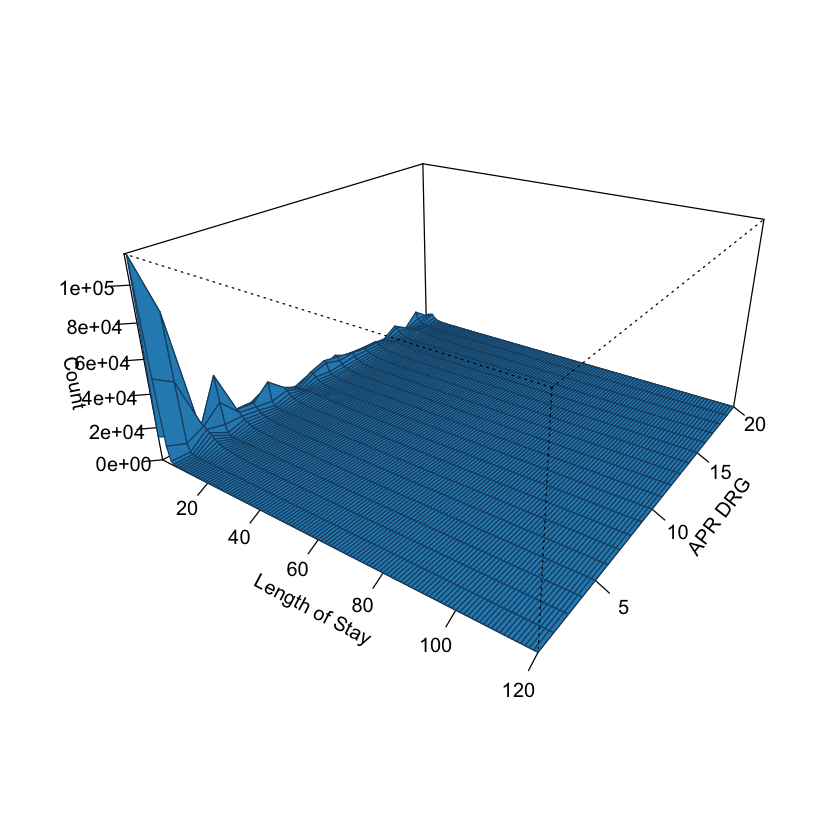

In [89]:
persp(
  x = x_vals,
  y = y_vals,
  z = z_matrix,
  theta = 35,
  phi = 25,
  expand = 0.5,
  col = paper_blue,
  border = paper_edge,
  ticktype = "detailed",
  xlab = "Length of Stay",
  ylab = "APR DRG",
  zlab = "Count",
  main = ""
)

In [90]:
png(
  filename = file.path(figure_path, "Figure_06_Top20_APR_DRG_Length_of_Stay_3D.png"),
  width = 2400,
  height = 1800,
  res = 300,
  bg = "white"
)

persp(
  x = x_vals,
  y = y_vals,
  z = z_matrix,
  theta = 35,
  phi = 25,
  expand = 0.5,
  col = paper_blue,
  border = paper_edge,
  ticktype = "detailed",
  xlab = "Length of Stay",
  ylab = "APR DRG",
  zlab = "Count",
  main = ""
)

dev.off()

agg_record_9b9f21e032a1 
                      2

## 3.11 Reanalysis：類別變項描述性統計

本節補充建立主要類別變項之描述性統計，作為後續特徵工程與模型建立的基礎。此部分屬於本專案再分析，不屬於原論文 Figure 3–6 的直接重現。

In [91]:
categorical_summary <- function(data, variable) {

  result <- data %>%
    dplyr::count(.data[[variable]]) %>%
    dplyr::rename(
      Category = 1,
      Frequency = n
    ) %>%
    dplyr::mutate(
      Category = as.character(Category),
      Percentage = round(Frequency / sum(Frequency) * 100, 2),
      Variable = variable,
      .before = 1
    ) %>%
    dplyr::select(
      Variable,
      Category,
      Frequency,
      Percentage
    )

  return(result)
}

categorical_variables <- c(
  "Gender",
  "Age Group",
  "Race",
  "Ethnicity",
  "Type of Admission",
  "Patient Disposition",
  "APR Severity of Illness Code",
  "APR Risk of Mortality",
  "APR Medical Surgical Description",
  "Payment Typology 1",
  "Emergency Department Indicator"
)

table1_categorical <- purrr::map_dfr(
  categorical_variables,
  ~ categorical_summary(df_clean, .x)
)

table1_categorical

Variable,Category,Frequency,Percentage
<chr>,<chr>,<int>,<dbl>
Gender,F,1297283,55.48
Gender,M,1040797,44.51
Gender,U,24,0.00
Age Group,0 to 17,347084,14.84
Age Group,18 to 29,241777,10.34
Age Group,30 to 49,452633,19.36
Age Group,50 to 69,654214,27.98
Age Group,70 or Older,642396,27.48
Race,Black/African American,428736,18.34


In [92]:
write.csv(
  table1_categorical,
  file.path(output_path, "Reanalysis_Categorical_Characteristics.csv"),
  row.names = FALSE
)

## 3.12 Reanalysis：Newborn 與 Non-newborn LoS 比較

由於原論文將 newborn 與 non-newborn 分開建模，本節比較兩組 LoS 描述性統計。

In [93]:
los_by_group <- bind_rows(
  df_newborn %>%
    mutate(Group = "Newborn") %>%
    select(Group, Length_of_Stay_Days),
  df_non_newborn %>%
    mutate(Group = "Non-newborn") %>%
    select(Group, Length_of_Stay_Days)
)

group_los_summary <- los_by_group %>%
  group_by(Group) %>%
  summarise(
    N = n(),
    Mean = round(mean(Length_of_Stay_Days, na.rm = TRUE), 2),
    SD = round(sd(Length_of_Stay_Days, na.rm = TRUE), 2),
    Median = round(median(Length_of_Stay_Days, na.rm = TRUE), 2),
    Q1 = round(as.numeric(quantile(Length_of_Stay_Days, 0.25, na.rm = TRUE)), 2),
    Q3 = round(as.numeric(quantile(Length_of_Stay_Days, 0.75, na.rm = TRUE)), 2),
    .groups = "drop"
  )

group_los_summary

Group,N,Mean,SD,Median,Q1,Q3
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Newborn,229290,3.83,8.39,2,2,3
Non-newborn,2108814,5.59,7.90,3,2,6


In [94]:
write.csv(
  group_los_summary,
  file.path(output_path, "Reanalysis_LOS_by_Newborn_Status.csv"),
  row.names = FALSE
)

## 3.13 EDA 小結

本章依據 Jain et al. (2024) 的 Results 順序，重現與描述性統計相關的主要圖表與表格。

目前資料的 LoS 描述性統計與原論文 Table 1 高度一致，平均值約為 5.41 天，中位數為 3 天，最大值為 120 天。LoS 分布呈現明顯右偏，且在長住院天數處呈現長尾分布，與原論文 Figure 3 與 Figure 4 的趨勢相符。

新生兒族群之 LoS 分布集中於短天數，符合原論文將 newborn 與 non-newborn 分開建模的策略。APR DRG 分布呈現高度不平衡，少數 DRG 類別占據大量住院事件，後續在 04_Feature_Engineering.ipynb 中需進一步處理類別變項編碼與分層建模。